In [1]:
import os
import sys
import pandas as pd
sys.path.append(os.path.abspath(os.path.join('..')))

# Reading the Data

In [2]:
train = pd.read_csv("../data/raw/train_BRCpofr.csv.zip", compression="zip")
test = pd.read_csv("../data/raw/test_koRSKBP.csv.zip", compression="zip")

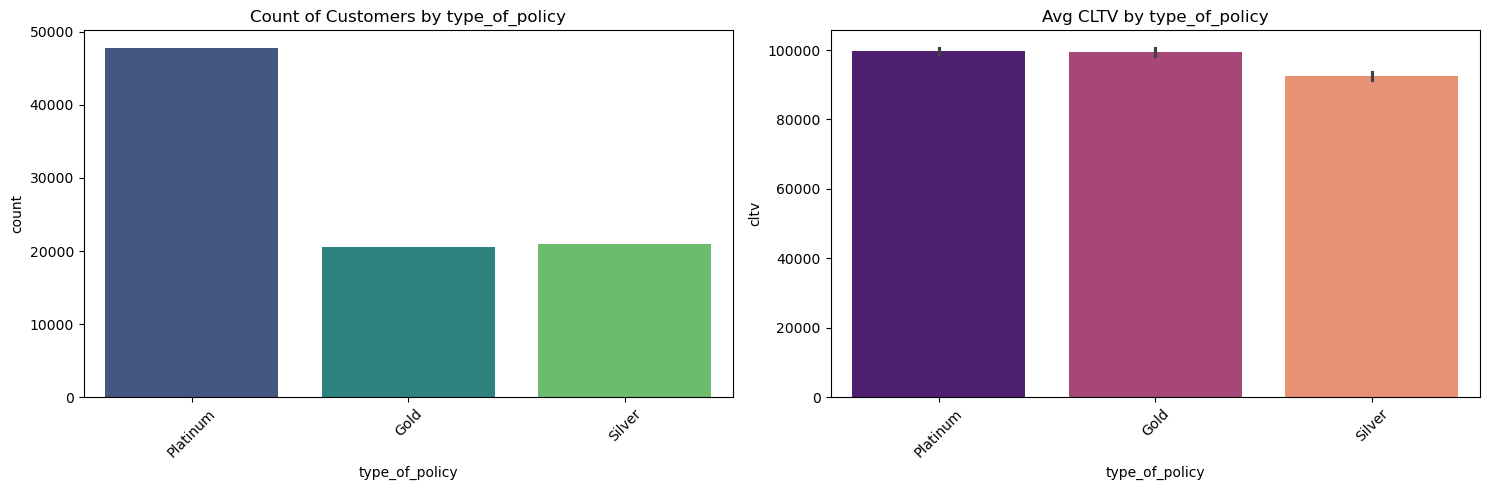

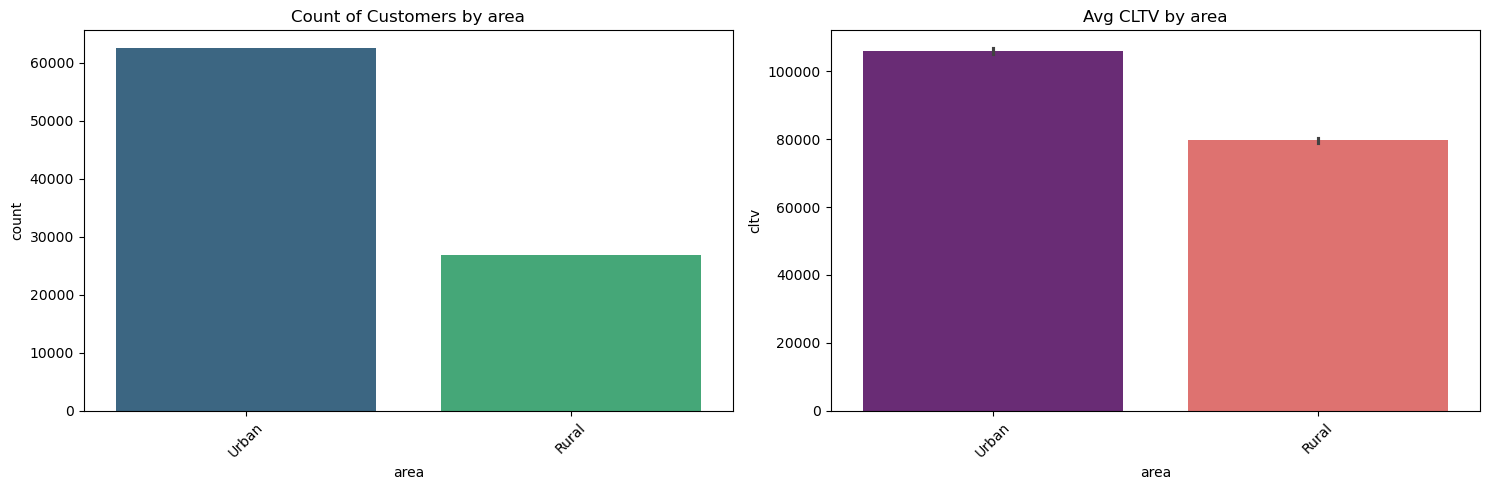

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def analyze_categorical(df, col, target='cltv'):
    """
    Creates a dual-plot analysis:
    1. Count of customers per category
    2. Average CLTV per category
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Distribution
    sns.countplot(data=df, x=col, ax=axes[0], palette='viridis', hue=col)
    axes[0].set_title(f'Count of Customers by {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Average CLTV
    sns.barplot(data=df, x=col, y=target, ax=axes[1], palette='magma', hue=col)
    axes[1].set_title(f'Avg CLTV by {col}')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# Now call it for your key columns
analyze_categorical(train, 'type_of_policy')
analyze_categorical(train, 'area')

In [4]:


def plot_categorical_insight(data, feature):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left plot: Volume
    sns.countplot(data=data, x=feature,
                  ax=axes[0], palette='viridis', hue=feature)
    axes[0].set_title(f"Customer Distribution by {feature}", fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)

    # Right plot: Value
    sns.barplot(data=data, x=feature, y='cltv',
                ax=axes[1], palette='magma', hue=feature)
    axes[1].set_title(f"Average CLTV by {feature}", fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

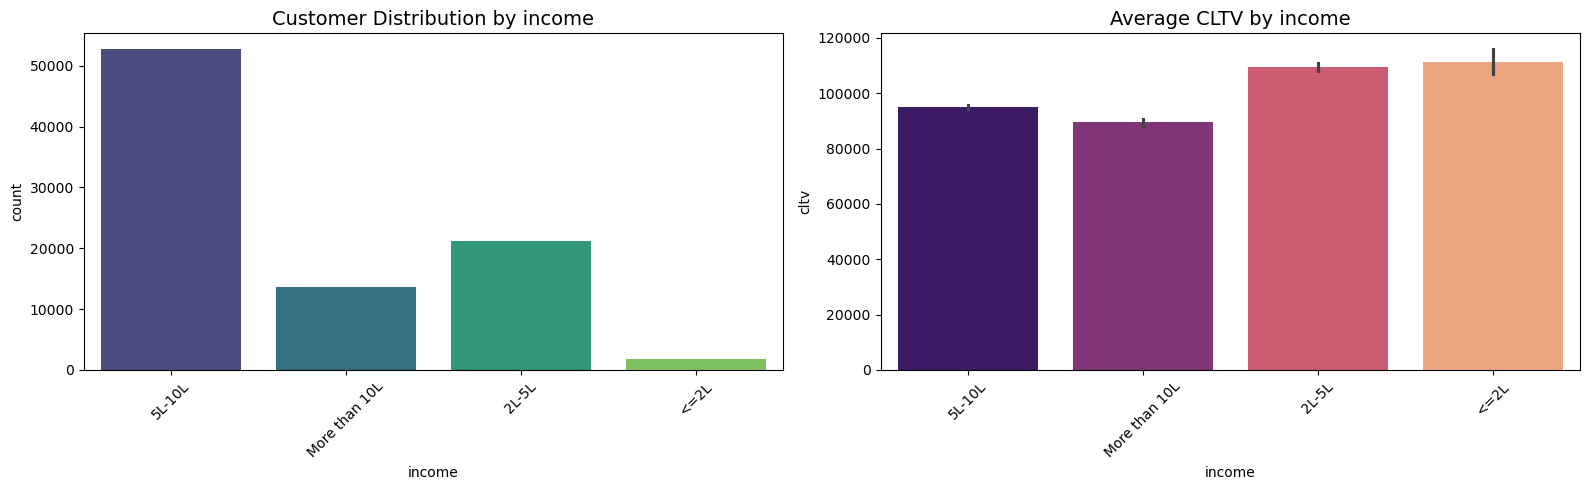

In [5]:
plot_categorical_insight(train, 'income')

While the 5L-10L has the highest customer volumes, 2L-5L and <=2L customers has the highest the highest average customer lifetime value.
This shows that the wealthy customers are not the highest value customer. The low income customers might be more loyal or tend to buy more specific high margin packages.

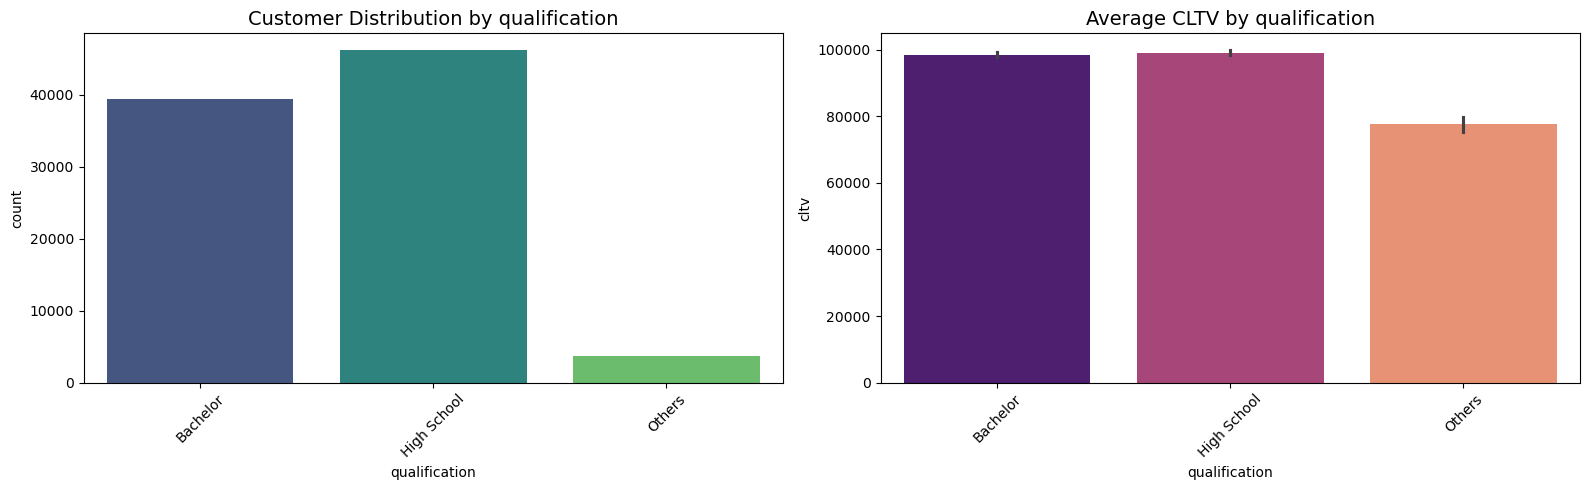

In [6]:
plot_categorical_insight(train, 'qualification')

Bachelor and High School groups have almost identical average CLTVs, but the Others category significantly underperforms. 
The product tends to the general public but  might need a tailored marketing approach to stimulate Others category.